# Perbandingan Model Forecasting: XGBoost vs LSTM vs GRU

Notebook ini membandingkan tiga model untuk forecasting `ALLSKY_SFC_SW_DWN` 24 jam ke depan pada dataset representative point per `REP_NAME`.

Setup evaluasi:
- Target: `ALLSKY_SFC_SW_DWN`
- Lookback: 24 jam
- Horizon: 24 jam
- Split: time-based split
- Fitur input: `CLOUD_AMT`, `T2M`, `RH2M`, `PS`, `CLRSKY_SFC_SW_DWN` + fitur waktu
- Default eksperimen: `Jawa`

Catatan penting:
- Sentinel missing `-999` dibersihkan sebelum training dan evaluasi.
- XGBoost memakai input sequence yang di-flatten, sedangkan LSTM/GRU memakai input sequence 3D.
- Notebook ini fokus pada komparasi yang fair, jadi preprocessing dan split dibuat sama untuk ketiga model.

In [1]:
# Jalankan sekali jika environment belum punya dependency.
# %pip install pandas numpy scikit-learn matplotlib joblib torch xgboost jupyter notebook ipykernel


In [2]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device aktif: {DEVICE}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Device aktif: cuda
NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
DATA_PATH = Path('nasa_dataset_daily_20200101_20260101_representative_point_area.csv')
TARGET_COL = 'ALLSKY_SFC_SW_DWN'
BASE_FEATURES = ['CLOUD_AMT', 'T2M', 'RH2M', 'PS', 'CLRSKY_SFC_SW_DWN']
TIME_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos']
FEATURE_COLS = BASE_FEATURES + TIME_FEATURES
LOOKBACK = 24
HORIZON = 24
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
MISSING_SENTINEL = -999.0
DEFAULT_REGION = 'Jawa'

REP_NAME_ALIASES = {
    'Sumatra': 'Sumatera',
    'Bali_Nusa': 'Nusa Tenggara',
    'NTB_NTT': 'Nusa Tenggara',
}

def normalize_rep_name(rep_name: str) -> str:
    return REP_NAME_ALIASES.get(rep_name, rep_name)


def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['REP_NAME'] = df['REP_NAME'].astype(str).map(normalize_rep_name)
    numeric_cols = BASE_FEATURES + [TARGET_COL]
    df[numeric_cols] = df[numeric_cols].replace(MISSING_SENTINEL, np.nan)
    df['datetime'] = pd.to_datetime(dict(year=df['YEAR'], month=df['MO'], day=df['DY'], hour=df['HR']))
    df = df.sort_values(['REP_NAME', 'datetime']).reset_index(drop=True)
    df['hour_sin'] = np.sin(2 * np.pi * df['HR'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['HR'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['MO'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['MO'] / 12)
    df['dayofyear'] = df['datetime'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 366)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 366)
    return df


df_all = load_dataset(DATA_PATH)
print(df_all[['REP_NAME'] + BASE_FEATURES + [TARGET_COL]].head())
print('\nMissing values after sentinel cleanup:')
print(df_all[BASE_FEATURES + [TARGET_COL]].isna().sum())


  REP_NAME  CLOUD_AMT    T2M   RH2M     PS  CLRSKY_SFC_SW_DWN  \
0     Jawa      98.61  25.34  89.43  98.67             394.12   
1     Jawa      98.83  25.93  83.58  98.73             622.78   
2     Jawa      99.72  26.94  78.75  98.74             809.80   
3     Jawa      99.99  28.08  75.40  98.70             936.25   
4     Jawa      99.71  28.58  75.06  98.65             991.17   

   ALLSKY_SFC_SW_DWN  
0             268.55  
1             441.62  
2             610.35  
3             575.12  
4             518.35  

Missing values after sentinel cleanup:
CLOUD_AMT            168
T2M                    0
RH2M                   0
PS                     0
CLRSKY_SFC_SW_DWN    168
ALLSKY_SFC_SW_DWN    168
dtype: int64


In [4]:
def time_based_split(region_df: pd.DataFrame, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO):
    n = len(region_df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return region_df.iloc[:train_end].copy(), region_df.iloc[train_end:val_end].copy(), region_df.iloc[val_end:].copy()


def create_sequences(feature_array: np.ndarray, target_array: np.ndarray, lookback: int = LOOKBACK, horizon: int = HORIZON):
    X, y = [], []
    max_start = len(feature_array) - lookback - horizon + 1
    for start_idx in range(max_start):
        end_idx = start_idx + lookback
        horizon_end = end_idx + horizon
        X.append(feature_array[start_idx:end_idx])
        y.append(target_array[end_idx:horizon_end, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def prepare_region_data(df: pd.DataFrame, region_name: str):
    region_name = normalize_rep_name(region_name)
    region_df = df.loc[df['REP_NAME'] == region_name].copy()
    required_cols = BASE_FEATURES + [TARGET_COL]
    dropped_missing_rows = int(region_df[required_cols].isna().any(axis=1).sum())
    region_df = region_df.dropna(subset=required_cols).copy()

    train_df, val_df, test_df = time_based_split(region_df)
    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        if len(split_df) < LOOKBACK + HORIZON:
            raise ValueError(f'Split {split_name} terlalu kecil untuk lookback/horizon.')

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    train_X_scaled = x_scaler.fit_transform(train_df[FEATURE_COLS].values)
    val_X_scaled = x_scaler.transform(val_df[FEATURE_COLS].values)
    test_X_scaled = x_scaler.transform(test_df[FEATURE_COLS].values)

    train_y_scaled = y_scaler.fit_transform(train_df[[TARGET_COL]].values)
    val_y_scaled = y_scaler.transform(val_df[[TARGET_COL]].values)
    test_y_scaled = y_scaler.transform(test_df[[TARGET_COL]].values)

    X_train, y_train = create_sequences(train_X_scaled, train_y_scaled)
    X_val, y_val = create_sequences(val_X_scaled, val_y_scaled)
    X_test, y_test = create_sequences(test_X_scaled, test_y_scaled)

    return {
        'region_name': region_name,
        'dropped_missing_rows': dropped_missing_rows,
        'feature_columns': FEATURE_COLS,
        'x_scaler': x_scaler,
        'y_scaler': y_scaler,
        'X_train_seq': X_train,
        'y_train': y_train,
        'X_val_seq': X_val,
        'y_val': y_val,
        'X_test_seq': X_test,
        'y_test': y_test,
        'X_train_flat': X_train.reshape(X_train.shape[0], -1),
        'X_val_flat': X_val.reshape(X_val.shape[0], -1),
        'X_test_flat': X_test.reshape(X_test.shape[0], -1),
        'train_range': (train_df['datetime'].min(), train_df['datetime'].max()),
        'val_range': (val_df['datetime'].min(), val_df['datetime'].max()),
        'test_range': (test_df['datetime'].min(), test_df['datetime'].max()),
    }


bundle = prepare_region_data(df_all, DEFAULT_REGION)
print('Region:', bundle['region_name'])
print('Dropped missing rows:', bundle['dropped_missing_rows'])
print('X_train_seq:', bundle['X_train_seq'].shape)
print('X_train_flat:', bundle['X_train_flat'].shape)
print('Train range:', bundle['train_range'])
print('Val range  :', bundle['val_range'])
print('Test range :', bundle['test_range'])


Region: Jawa
Dropped missing rows: 24
X_train_seq: (36778, 24, 11)
X_train_flat: (36778, 264)
Train range: (Timestamp('2020-01-01 00:00:00'), Timestamp('2024-03-14 08:00:00'))
Val range  : (Timestamp('2024-03-14 09:00:00'), Timestamp('2025-02-06 03:00:00'))
Test range : (Timestamp('2025-02-06 04:00:00'), Timestamp('2025-12-31 23:00:00'))


In [5]:
def inverse_transform_targets(y_scaled: np.ndarray, scaler: MinMaxScaler) -> np.ndarray:
    original_shape = y_scaled.shape
    flat = y_scaled.reshape(-1, 1)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(original_shape)


def evaluate_forecast(y_true_scaled: np.ndarray, y_pred_scaled: np.ndarray, y_scaler: MinMaxScaler):
    y_true = inverse_transform_targets(y_true_scaled, y_scaler)
    y_pred = inverse_transform_targets(y_pred_scaled, y_scaler)
    rmse = float(np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))))
    mae = float(mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)))
    rmse_per_horizon = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    mae_per_horizon = np.mean(np.abs(y_true - y_pred), axis=0)
    return {
        'rmse_all_steps': rmse,
        'mae_all_steps': mae,
        'rmse_per_horizon': rmse_per_horizon,
        'mae_per_horizon': mae_per_horizon,
        'y_true': y_true,
        'y_pred': y_pred,
    }


In [6]:
class RecurrentForecaster(nn.Module):
    def __init__(self, input_size: int, rnn_type: str = 'lstm', hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2, horizon: int = HORIZON):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type.lower() == 'lstm' else nn.GRU
        rnn_dropout = dropout if num_layers > 1 else 0.0
        self.rnn_type = rnn_type.lower()
        self.rnn = rnn_cls(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=rnn_dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


def train_torch_model(model_name: str, model: nn.Module, X_train: np.ndarray, y_train: np.ndarray, X_val: np.ndarray, y_val: np.ndarray, X_test: np.ndarray, y_test: np.ndarray, y_scaler: MinMaxScaler, epochs: int = 25, batch_size: int = 64, learning_rate: float = 1e-3):
    train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)), batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=batch_size, shuffle=False)

    model = model.to(DEVICE)
    criterion = nn.HuberLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience = 6
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(DEVICE)
                batch_y = batch_y.to(DEVICE)
                val_losses.append(criterion(model(batch_x), batch_y).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)
        print(f'{model_name} | epoch {epoch:02d}/{epochs} | train={train_loss:.5f} | val={val_loss:.5f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'{model_name} early stopping.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            preds.append(model(batch_x.to(DEVICE)).cpu().numpy())
            targets.append(batch_y.numpy())

    y_pred_scaled = np.concatenate(preds, axis=0)
    y_true_scaled = np.concatenate(targets, axis=0)
    metrics = evaluate_forecast(y_true_scaled, y_pred_scaled, y_scaler)
    return {'model': model, 'history': history, 'metrics': metrics}


def train_xgboost_model(X_train_flat: np.ndarray, y_train: np.ndarray, X_val_flat: np.ndarray, y_val: np.ndarray, X_test_flat: np.ndarray, y_test: np.ndarray, y_scaler: MinMaxScaler):
    estimators = []
    train_rmse_histories = []
    val_rmse_histories = []

    for horizon_idx in range(y_train.shape[1]):
        estimator = XGBRegressor(
            objective='reg:squarederror',
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            tree_method='hist',
            eval_metric='rmse',
            random_state=SEED,
            n_jobs=-1,
        )
        estimator.fit(
            X_train_flat,
            y_train[:, horizon_idx],
            eval_set=[(X_train_flat, y_train[:, horizon_idx]), (X_val_flat, y_val[:, horizon_idx])],
            verbose=False,
        )
        evals_result = estimator.evals_result()
        train_rmse_histories.append(evals_result['validation_0']['rmse'])
        val_rmse_histories.append(evals_result['validation_1']['rmse'])
        estimators.append(estimator)

    y_pred_scaled = np.column_stack([estimator.predict(X_test_flat) for estimator in estimators]).astype(np.float32)
    metrics = evaluate_forecast(y_test, y_pred_scaled, y_scaler)
    history = {
        'train_rmse': np.mean(np.array(train_rmse_histories, dtype=np.float32), axis=0).tolist(),
        'val_rmse': np.mean(np.array(val_rmse_histories, dtype=np.float32), axis=0).tolist(),
    }
    return {'model': estimators, 'metrics': metrics, 'history': history}


In [7]:
results = {}

results['XGBoost'] = train_xgboost_model(
    bundle['X_train_flat'],
    bundle['y_train'],
    bundle['X_val_flat'],
    bundle['y_val'],
    bundle['X_test_flat'],
    bundle['y_test'],
    bundle['y_scaler'],
)

results['LSTM'] = train_torch_model(
    model_name='LSTM',
    model=RecurrentForecaster(input_size=len(FEATURE_COLS), rnn_type='lstm'),
    X_train=bundle['X_train_seq'],
    y_train=bundle['y_train'],
    X_val=bundle['X_val_seq'],
    y_val=bundle['y_val'],
    X_test=bundle['X_test_seq'],
    y_test=bundle['y_test'],
    y_scaler=bundle['y_scaler'],
    epochs=25,
    batch_size=64,
)

results['GRU'] = train_torch_model(
    model_name='GRU',
    model=RecurrentForecaster(input_size=len(FEATURE_COLS), rnn_type='gru'),
    X_train=bundle['X_train_seq'],
    y_train=bundle['y_train'],
    X_val=bundle['X_val_seq'],
    y_val=bundle['y_val'],
    X_test=bundle['X_test_seq'],
    y_test=bundle['y_test'],
    y_scaler=bundle['y_scaler'],
    epochs=25,
    batch_size=64,
)

comparison_df = pd.DataFrame([
    {
        'model': model_name,
        'rmse_all_steps': result['metrics']['rmse_all_steps'],
        'mae_all_steps': result['metrics']['mae_all_steps'],
        'rmse_horizon_1': float(result['metrics']['rmse_per_horizon'][0]),
        'rmse_horizon_24': float(result['metrics']['rmse_per_horizon'][-1]),
    }
    for model_name, result in results.items()
]).sort_values('rmse_all_steps').reset_index(drop=True)

comparison_df


LSTM | epoch 01/25 | train=0.00829 | val=0.00441
LSTM | epoch 02/25 | train=0.00367 | val=0.00356
LSTM | epoch 03/25 | train=0.00338 | val=0.00346
LSTM | epoch 04/25 | train=0.00325 | val=0.00365
LSTM | epoch 05/25 | train=0.00317 | val=0.00365
LSTM | epoch 06/25 | train=0.00309 | val=0.00367
LSTM | epoch 07/25 | train=0.00307 | val=0.00367
LSTM | epoch 08/25 | train=0.00300 | val=0.00277
LSTM | epoch 09/25 | train=0.00299 | val=0.00292
LSTM | epoch 10/25 | train=0.00296 | val=0.00284
LSTM | epoch 11/25 | train=0.00297 | val=0.00277
LSTM | epoch 12/25 | train=0.00296 | val=0.00348
LSTM | epoch 13/25 | train=0.00295 | val=0.00283
LSTM | epoch 14/25 | train=0.00295 | val=0.00333
LSTM early stopping.
GRU | epoch 01/25 | train=0.00742 | val=0.00324
GRU | epoch 02/25 | train=0.00361 | val=0.00339
GRU | epoch 03/25 | train=0.00336 | val=0.00320
GRU | epoch 04/25 | train=0.00324 | val=0.00341
GRU | epoch 05/25 | train=0.00316 | val=0.00314
GRU | epoch 06/25 | train=0.00310 | val=0.00291
GRU |

,model,rmse_all_steps,mae_all_steps,rmse_horizon_1,rmse_horizon_24
0,XGBoost,61.957348,30.288828,46.355167,65.559967
1,GRU,69.563400,43.579613,65.097359,71.623077
2,LSTM,77.918625,48.802570,69.752457,77.804688


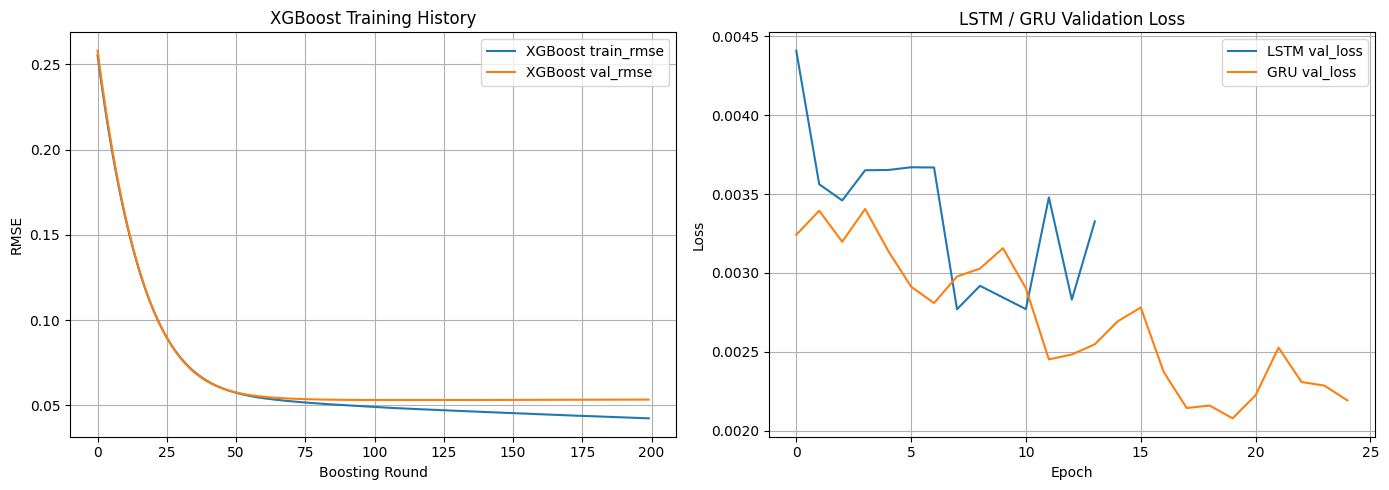

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['XGBoost']['history']['train_rmse'], label='XGBoost train_rmse')
axes[0].plot(results['XGBoost']['history']['val_rmse'], label='XGBoost val_rmse')
axes[0].set_title('XGBoost Training History')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('RMSE')
axes[0].grid(True)
axes[0].legend()

for model_name in ['LSTM', 'GRU']:
    history = results[model_name]['history']
    axes[1].plot(history['val_loss'], label=f'{model_name} val_loss')
axes[1].set_title('LSTM / GRU Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


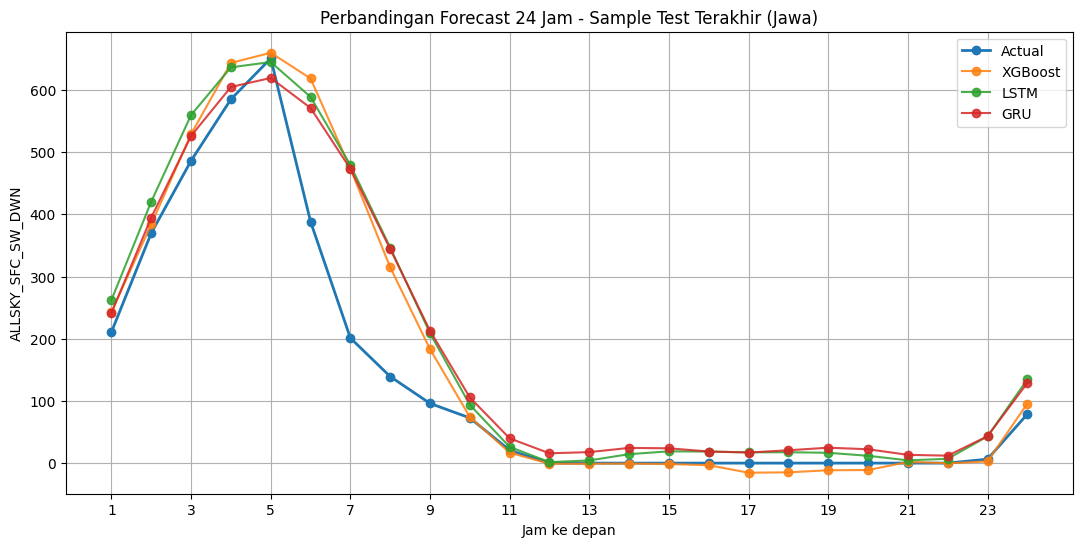

In [9]:
sample_idx = -1
y_true = results['LSTM']['metrics']['y_true'][sample_idx]

plt.figure(figsize=(13, 6))
plt.plot(range(1, HORIZON + 1), y_true, marker='o', linewidth=2, label='Actual')
for model_name, color in [('XGBoost', 'tab:orange'), ('LSTM', 'tab:green'), ('GRU', 'tab:red')]:
    y_pred = results[model_name]['metrics']['y_pred'][sample_idx]
    plt.plot(range(1, HORIZON + 1), y_pred, marker='o', label=model_name, alpha=0.85)
plt.title(f'Perbandingan Forecast 24 Jam - Sample Test Terakhir ({bundle["region_name"]})')
plt.xlabel('Jam ke depan')
plt.ylabel(TARGET_COL)
plt.xticks(range(1, HORIZON + 1, 2))
plt.grid(True)
plt.legend()
plt.show()


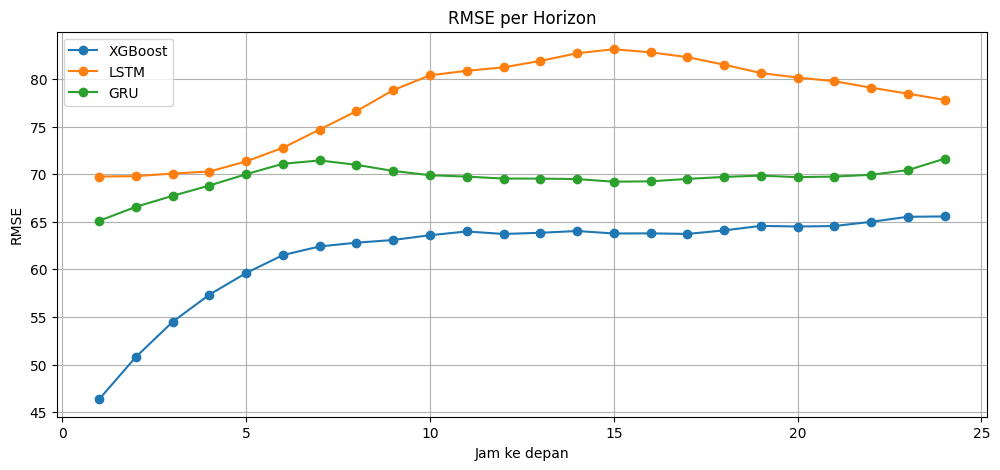

,horizon_hour,XGBoost,LSTM,GRU
0,1,46.355167,69.752457,65.097359
1,2,50.799393,69.791809,66.572395
2,3,54.490826,70.064606,67.726082
3,4,57.344090,70.276062,68.808304
4,5,59.616516,71.343575,69.998489


In [10]:
rmse_horizon_df = pd.DataFrame({
    'horizon_hour': np.arange(1, HORIZON + 1),
    'XGBoost': results['XGBoost']['metrics']['rmse_per_horizon'],
    'LSTM': results['LSTM']['metrics']['rmse_per_horizon'],
    'GRU': results['GRU']['metrics']['rmse_per_horizon'],
})

plt.figure(figsize=(12, 5))
for model_name in ['XGBoost', 'LSTM', 'GRU']:
    plt.plot(rmse_horizon_df['horizon_hour'], rmse_horizon_df[model_name], marker='o', label=model_name)
plt.title('RMSE per Horizon')
plt.xlabel('Jam ke depan')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plt.show()

rmse_horizon_df.head()


## Langkah berikutnya

Jika ingin memperluas eksperimen ke semua pulau, gunakan fungsi `prepare_region_data(...)` dan blok training yang sama lalu loop per `REP_NAME`.

Beberapa upgrade yang berguna setelah notebook ini:
- tambah baseline persistence sebagai pembanding minimum
- simpan artifact model terbaik per pulau dan per arsitektur
- lakukan tuning hyperparameter terpisah untuk XGBoost, LSTM, dan GRU
- evaluasi metrik khusus jam siang untuk target radiasi surya